# 10 — Orders & Execution

## What you'll learn
- What an **order** is — an instruction, not an execution — and its lifecycle `open → filled / canceled / rejected`.
- The six order helpers: **market**, **limit**, and **stop** orders, on either side (buy / sell), and when a trader reaches for each.
- How a **take-profit / stop-loss bracket** attaches two resting exits to one entry.
- How a **paper broker** replays historical bars: which orders fill, at which price, and what cash does.
- Why a market order fills at the **next** bar's open — a price the signal could not have known.
- The difference between an order that has *not filled yet* and one that has been *canceled*.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from stocklearn.data import get_history, price_series
from stocklearn.orders import (Order, Side, OrderStatus,
                               market_buy, market_sell, limit_buy, limit_sell,
                               stop_buy, stop_sell)
from stocklearn.broker import PaperBroker, bars_from_history

sns.set_theme(style="whitegrid")

# One place to swap the symbol.
ticker = "AAPL"
period = "1y"


## An order is an intent, not an execution

When you "buy 10 shares" you have not bought anything yet — you have submitted an **order**: a
small instruction saying *what*, *how much*, and *under which price condition*. Only the broker
turns that instruction into a fill.

Every order moves through four states:

| State | Meaning | Who moves it there |
|---|---|---|
| `open` | submitted and resting; nothing has happened yet | **you**, when you place it |
| `filled` | executed — shares and cash changed hands | the **broker**, when a bar satisfies the price |
| `canceled` | withdrawn before it filled | **you**, by calling `cancel()` |
| `rejected` | the broker refused to execute it at fill time | the **broker** (e.g. not enough cash) |

`open` is the only non-terminal state: an order either fills, is canceled, or is rejected.


In [2]:
examples = [
    market_buy(10),          # buy now, at whatever the next open is
    limit_buy(10, 100.0),    # buy, but never above 100
    stop_buy(10, 300.0),     # buy only if price breaks up through 300
    market_sell(5),          # sell now
    limit_sell(5, 300.0),    # sell, but never below 300
    stop_sell(5, 100.0),     # sell only if price breaks down through 100
]

print("Every fresh order starts open, and order_id increments:")
for o in examples:
    print(f"  {str(o):46s}  status={o.status.value}")


Every fresh order starts open, and order_id increments:
  #1 buy 10 AAPL market [open]                    status=open
  #2 buy 10 AAPL limit @ limit 100.0 [open]       status=open
  #3 buy 10 AAPL stop @ stop 300.0 [open]         status=open
  #4 sell 5 AAPL market [open]                    status=open
  #5 sell 5 AAPL limit @ limit 300.0 [open]       status=open
  #6 sell 5 AAPL stop @ stop 100.0 [open]         status=open


## Which type, and when

| Order | Fills when… | Fill price | Why a trader uses it |
|---|---|---|---|
| **market** buy/sell | the next bar opens (always) | next bar's **open** | **certainty of execution**, but you accept an unknown price |
| **limit** buy | the bar trades **down to** your price | your limit or better | **price control** — but it might never fill |
| **limit** sell | the bar trades **up to** your price | your limit or better | sell only at a price you like |
| **stop** buy | the bar trades **up through** your price | at/above your stop | enter on a **breakout** confirmation |
| **stop** sell | the bar trades **down through** your price | at/below your stop | exit on a **breakdown** (a protective stop) |

A **limit** order says *"only at this price or better."* A **stop** order says *"do nothing until
price crosses this trigger, then get me in (or out) at market."* Notice the string form above
carries the side, quantity, symbol, type, trigger price, and status — everything the broker needs.


In [3]:
# A bracket turns one buy entry into three decisions: enter, take profit, or bail out.
# take_profit must sit ABOVE the entry and stop_loss BELOW it — they are resting exits
# that the broker watches once the position exists.
bracket = market_buy(10, take_profit=110.0, stop_loss=95.0)
print(str(bracket))
print(f"  take_profit={bracket.take_profit}  stop_loss={bracket.stop_loss}")
print(f"  take_profit above stop_loss? {bracket.take_profit > bracket.stop_loss}")

# Brackets belong to an ENTRY (a buy). A sell is an exit, so it must not carry them.
try:
    Order(side=Side.SELL, quantity=10, take_profit=110.0)
    print("no error (unexpected)")
except ValueError as exc:
    print("SELL with a bracket ->", type(exc).__name__, ":", exc)


#7 buy 10 AAPL market (TP 110.0 / SL 95.0) [open]
  take_profit=110.0  stop_loss=95.0
  take_profit above stop_loss? True
SELL with a bracket -> ValueError : take_profit / stop_loss only attach to BUY orders (entries)


## Bars: the broker's clock

A paper session never sees a live quote feed — it **replays bars**, one at a time.
`bars_from_history` turns the OHLC DataFrame into `Bar` objects; prices are put on the
**adjusted** scale (dividend/split-adjusted) so the price a strategy *signals on* and the price
an order *fills at* share one consistent basis.


In [4]:
df = get_history(ticker, period=period)
close = price_series(df)
bars = bars_from_history(df)

print(f"fetched {len(bars)} bars for {ticker}")
print("bars[:3] on the adjusted scale:")
for b in bars[:3]:
    print(f"  {b.timestamp:%Y-%m-%d}  open {b.open:8.2f}  high {b.high:8.2f}  "
          f"low {b.low:8.2f}  close {b.close:8.2f}")


fetched 251 bars for AAPL
bars[:3] on the adjusted scale:
  2025-10-03  open   253.73  high   258.29  low   253.02  close   257.07
  2025-10-06  open   257.04  high   258.12  low   254.11  close   255.75
  2025-10-07  open   255.86  high   256.45  low   254.49  close   255.54


## Placing an order queues it — nothing has happened yet

We will replay the **last 8 bars** so the fills line up with the prices we have just seen.
`place_order` only records the intent: the order sits in `broker.pending`, `broker.cash` is still
the full starting balance, and there is no position. A market order cannot fill the instant you
submit it — its price is the *next* bar's open, which does not exist yet.


In [5]:
walked = bars[-8:]

broker = PaperBroker(initial_cash=10_000.0)
mo = market_buy(10)
broker.place_order(mo)

print("pending:", [str(o) for o in broker.pending])
print("cash before any bar:", broker.cash)
print("positions before any bar:", dict(broker.positions))


pending: ['#9 buy 10 AAPL market [open]']
cash before any bar: 10000.0
positions before any bar: {}


In [6]:
for bar in walked[:3]:
    broker.next_bar(bar)
    pos = broker.positions.get(ticker)
    print(f"{bar.timestamp:%Y-%m-%d}  O {bar.open:7.2f} H {bar.high:7.2f} "
          f"L {bar.low:7.2f} C {bar.close:7.2f}")
    print(f"    order {mo.order_id}: status={mo.status.value:<7} "
          f"fill_price={mo.fill_price:.2f}")
    print(f"    cash={broker.cash:9.2f}  position="
          f"{('qty ' + str(pos.quantity) + ' @ avg ' + format(pos.avg_price, '.2f')) if pos else 'none'}")

# The accounting identity: cash spent == quantity * fill price
print(f"\ncheck: 10_000 - 10 * {mo.fill_price:.2f} = {10_000 - 10 * mo.fill_price:.2f}"
      f"   (broker.cash = {broker.cash:.2f})")


2026-09-23  O  341.08 H  341.80 L  335.50 C  337.02
    order 9: status=filled  fill_price=341.08
    cash=  6589.20  position=qty 10 @ avg 341.08
2026-09-24  O  336.72 H  338.91 L  334.30 C  335.92
    order 9: status=filled  fill_price=341.08
    cash=  6589.20  position=qty 10 @ avg 341.08
2026-09-25  O  336.04 H  341.67 L  334.53 C  341.07
    order 9: status=filled  fill_price=341.08
    cash=  6589.20  position=qty 10 @ avg 341.08

check: 10_000 - 10 * 341.08 = 6589.20   (broker.cash = 6589.20)


## The fill: the next bar's open

Look at the timing. The order was placed knowing only the prior close, and it filled at the
**first walked bar's open** — a price that arrived *after* the decision. That is exactly what
keeps a simulation honest: a signal computed from bar *i*'s close can only execute at bar *i+1*'s
open. An engine that fills at the signal bar's own close is quietly cheating (lookahead bias).
Note too that cash did not move until the bar arrived: `pending` → `filled`.


In [7]:
# A limit buy 10% below the latest close: clearly out of reach, so it just rests.
limit_price = round(float(close.iloc[-1]) * 0.9, 2)
lo = limit_buy(10, limit_price)
broker.place_order(lo)
print("placed:", str(lo))
print("resting in broker.pending?", lo in broker.pending)

for bar in walked[3:]:
    broker.next_bar(bar)

low_after = min(b.low for b in walked[3:])
print(f"after replaying {len(walked[3:])} more bars: lowest low {low_after:.2f} vs limit {limit_price:.2f}"
      f"  -> {'never touched, so it rests' if low_after > limit_price else 'the price reached it'}")
print(f"  order status : {lo.status.value}")
print(f"  still pending: {lo in broker.pending}")

print(f"cancel(#{lo.order_id}) -> {broker.cancel(lo.order_id)}   status now: {lo.status.value}")
print(f"cancel(#{lo.order_id}) again -> {broker.cancel(lo.order_id)}   (already terminal)")


placed: #10 buy 10 AAPL limit @ limit 300.32 [open]
resting in broker.pending? True
after replaying 5 more bars: lowest low 325.81 vs limit 300.32  -> never touched, so it rests
  order status : open
  still pending: True
cancel(#10) -> True   status now: canceled
cancel(#10) again -> False   (already terminal)


## "Not filled yet" vs "canceled"

The limit buy sat at **10% below** the last close. Price never came down to it, so the order
stayed `open` — resting, waiting, doing nothing to your cash or position. That is different from
`canceled`: canceling is an *action you take* to withdraw a still-open order. Once it is canceled
(or filled), the order is terminal, so a second `cancel()` returns `False`.


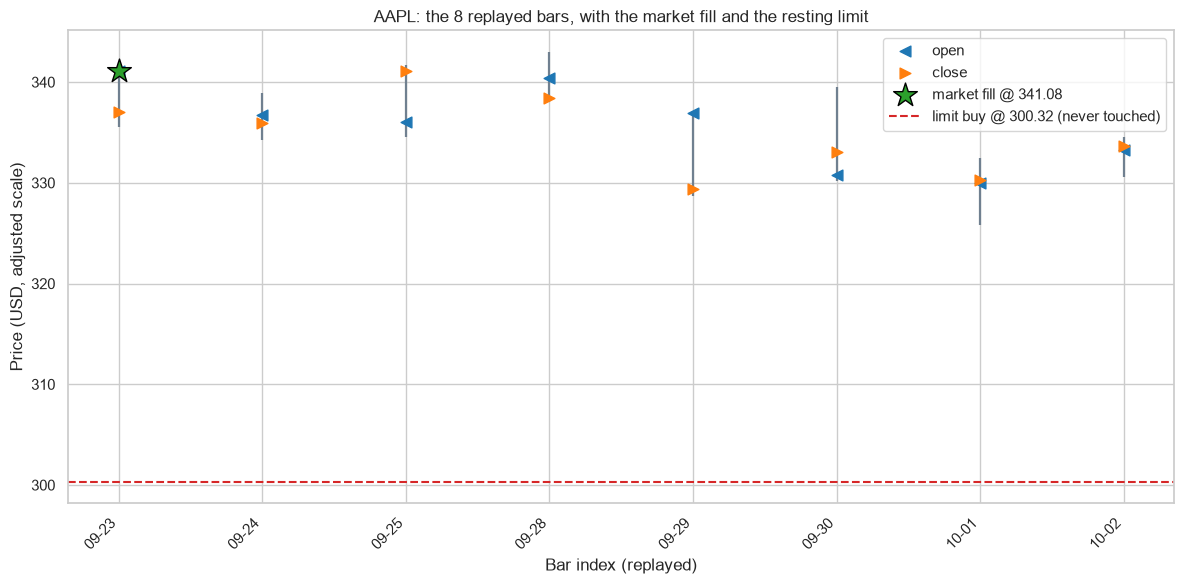

In [8]:
idx = np.arange(len(walked))
opens = np.array([b.open for b in walked])
highs = np.array([b.high for b in walked])
lows = np.array([b.low for b in walked])
closes = np.array([b.close for b in walked])
dates = [b.timestamp.strftime("%m-%d") for b in walked]

fig, ax = plt.subplots(figsize=(12, 6))
ax.vlines(idx, lows, highs, color="slategray", linewidth=1.6, zorder=2)
ax.scatter(idx, opens, marker="<", s=60, color="tab:blue", zorder=3, label="open")
ax.scatter(idx, closes, marker=">", s=60, color="tab:orange", zorder=3, label="close")
ax.scatter([0], [mo.fill_price], marker="*", s=320, color="tab:green",
           edgecolor="black", zorder=5, label=f"market fill @ {mo.fill_price:.2f}")
ax.axhline(limit_price, color="tab:red", linestyle="--", linewidth=1.5,
           label=f"limit buy @ {limit_price:.2f} (never touched)")
ax.set_title(f"{ticker}: the 8 replayed bars, with the market fill and the resting limit")
ax.set_xlabel("Bar index (replayed)")
ax.set_ylabel("Price (USD, adjusted scale)")
ax.set_xticks(idx)
ax.set_xticklabels(dates, rotation=45, ha="right")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


## Recap

1. An order is an **intent** with four states — `open → filled / canceled / rejected` — and only
   the broker converts an open order into a fill.
2. **Market** = certainty of execution at an unknown price; **limit** = price control with no
   certainty; **stop** = a trigger that becomes a market order on a break. A **bracket**
   (`take_profit` above, `stop_loss` below) attaches resting exits to a buy entry.
3. Orders fill on the **next** bar: the market buy executed at `walked[0].open`, and cash moved
   only at that moment — never when the order was placed.
4. An order that has *not filled yet* is still `open`; **canceled** is a deliberate withdrawal
   you performed. Re-canceling a terminal order returns `False`.

**Try this:** set `limit_price = round(float(close.iloc[-1]) * 0.99, 2)` — just below the last
close — and re-run. Does the very next bar's low reach it, and does the order fill instead of
staying open? Then try `round(float(close.iloc[-1]) * 1.01, 2)` with `stop_buy` and watch the
trigger fire only when price trades *up* through it.
